## Boxplots by Topology (aggregated over system size)

One combined figure with **5 stacked subplots** in order: **energy usage**, **CPU utilization**, **throughput**, **response time**, **failure rate**. **Violins:** `scale='width'`; `cut=2`; **all** run points. **Strip:** black points, white rim, larger markers. **On-plot:** **median** only — red marker same size as strip points (`#d62728`); no IQR box. **Violin:** blue outline. **Legend:** median. **Frames:** blue spines. Data: all `system_size` (5, 10, 20).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.collections import PolyCollection
from matplotlib.lines import Line2D

In [2]:
cwd = Path('.').resolve()
# Find repo root (directory containing 5_results_data/run_table.csv) by walking up
_run_table = Path('5_results_data') / 'run_table.csv'
_search = cwd
RUN_TABLE_PATH = None
for _ in range(6):
    candidate = _search / _run_table
    if candidate.exists():
        RUN_TABLE_PATH = candidate
        break
    _search = _search.parent
if RUN_TABLE_PATH is None:
    RUN_TABLE_PATH = cwd / _run_table  # fallback for clear error
# Outputs always go to 5_results_analysis/figures (whether cwd is notebooks/ or .ipynb_checkpoints/)
if cwd.name == 'notebooks':
    _base = cwd.parent
elif cwd.name == '.ipynb_checkpoints' and cwd.parent.name == 'notebooks':
    _base = cwd.parent.parent
else:
    _base = cwd
FIGURES_DIR = _base / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print("Data:", RUN_TABLE_PATH, "| Exists:", RUN_TABLE_PATH.exists())

Data: /home/irena/Documents/Research Project/topology-scale-mubench-replication/5_results_data/run_table.csv | Exists: True


In [3]:
df = pd.read_csv(RUN_TABLE_PATH)
df = df[df['__done'] == 'DONE'].copy()

TOPOLOGY_ORDER = [
    'sequential_fanout', 'parallel_fanout', 'chain_with_branching',
    'hierarchical_tree', 'probabilistic_tree', 'complex_mesh',
]
TOPOLOGY_LABELS = {
    'sequential_fanout': 'Seq FO', 'parallel_fanout': 'Par FO',
    'chain_with_branching': 'Chain', 'hierarchical_tree': 'Hierarchical',
    'probabilistic_tree': 'Probabilistic', 'complex_mesh': 'Mesh',
}

# Derived columns for plot: latency in s, energy in kJ (raw are ms and J)
df['avg_latency_s'] = df['avg_latency_ms'] / 1000
df['energy_kj'] = df['energy'] / 1000

METRIC_BLOCKS = [
    ('energy_kj', 'Energy usage (kJ)'),
    ('cpu_usage_avg', 'CPU utilization (cores)'),
    ('throughput_rps', 'Throughput (RPS)'),
    ('avg_latency_s', 'Response time (s)'),
    ('failure_rate', 'Failure rate (%)'),
]

df = df[df['topology'].isin(TOPOLOGY_ORDER)]
df['topology'] = pd.Categorical(df['topology'], categories=TOPOLOGY_ORDER, ordered=True)

# Scale fraction (0–1) to 0–100 for display when needed
_scale_pct = (
    ('cpu_usage_avg' in df.columns and df['cpu_usage_avg'].max() <= 1.5)
    or ('failure_rate' in df.columns and df['failure_rate'].max() <= 1.5)
)
if _scale_pct:
    df = df.copy()
    if 'cpu_usage_avg' in df.columns and df['cpu_usage_avg'].max() <= 1.5:
        df['cpu_usage_avg'] = df['cpu_usage_avg'] * 100
    if 'failure_rate' in df.columns and df['failure_rate'].max() <= 1.5:
        df['failure_rate'] = df['failure_rate'] * 100

print("Rows:", len(df), "| Topologies:", df['topology'].nunique(), "| Sizes:", sorted(df['system_size'].unique().tolist()))

Rows: 180 | Topologies: 6 | Sizes: [5, 10, 20]


In [4]:
def remove_outliers(series):
    """IQR-based outlier removal (like reference)."""
    if series is None or len(series) == 0:
        return series
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series[(series >= lower) & (series <= upper)]

/tmp/ipykernel_284821/3621494277.py:63: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_284821/3621494277.py:63: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_284821/3621494277.py:63: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


/tmp/ipykernel_284821/3621494277.py:63: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_284821/3621494277.py:63: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_284821/3621494277.py:133: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[-1].set_xticklabels(labels, rotation=30, ha='right', fontsize=FS_TICK)


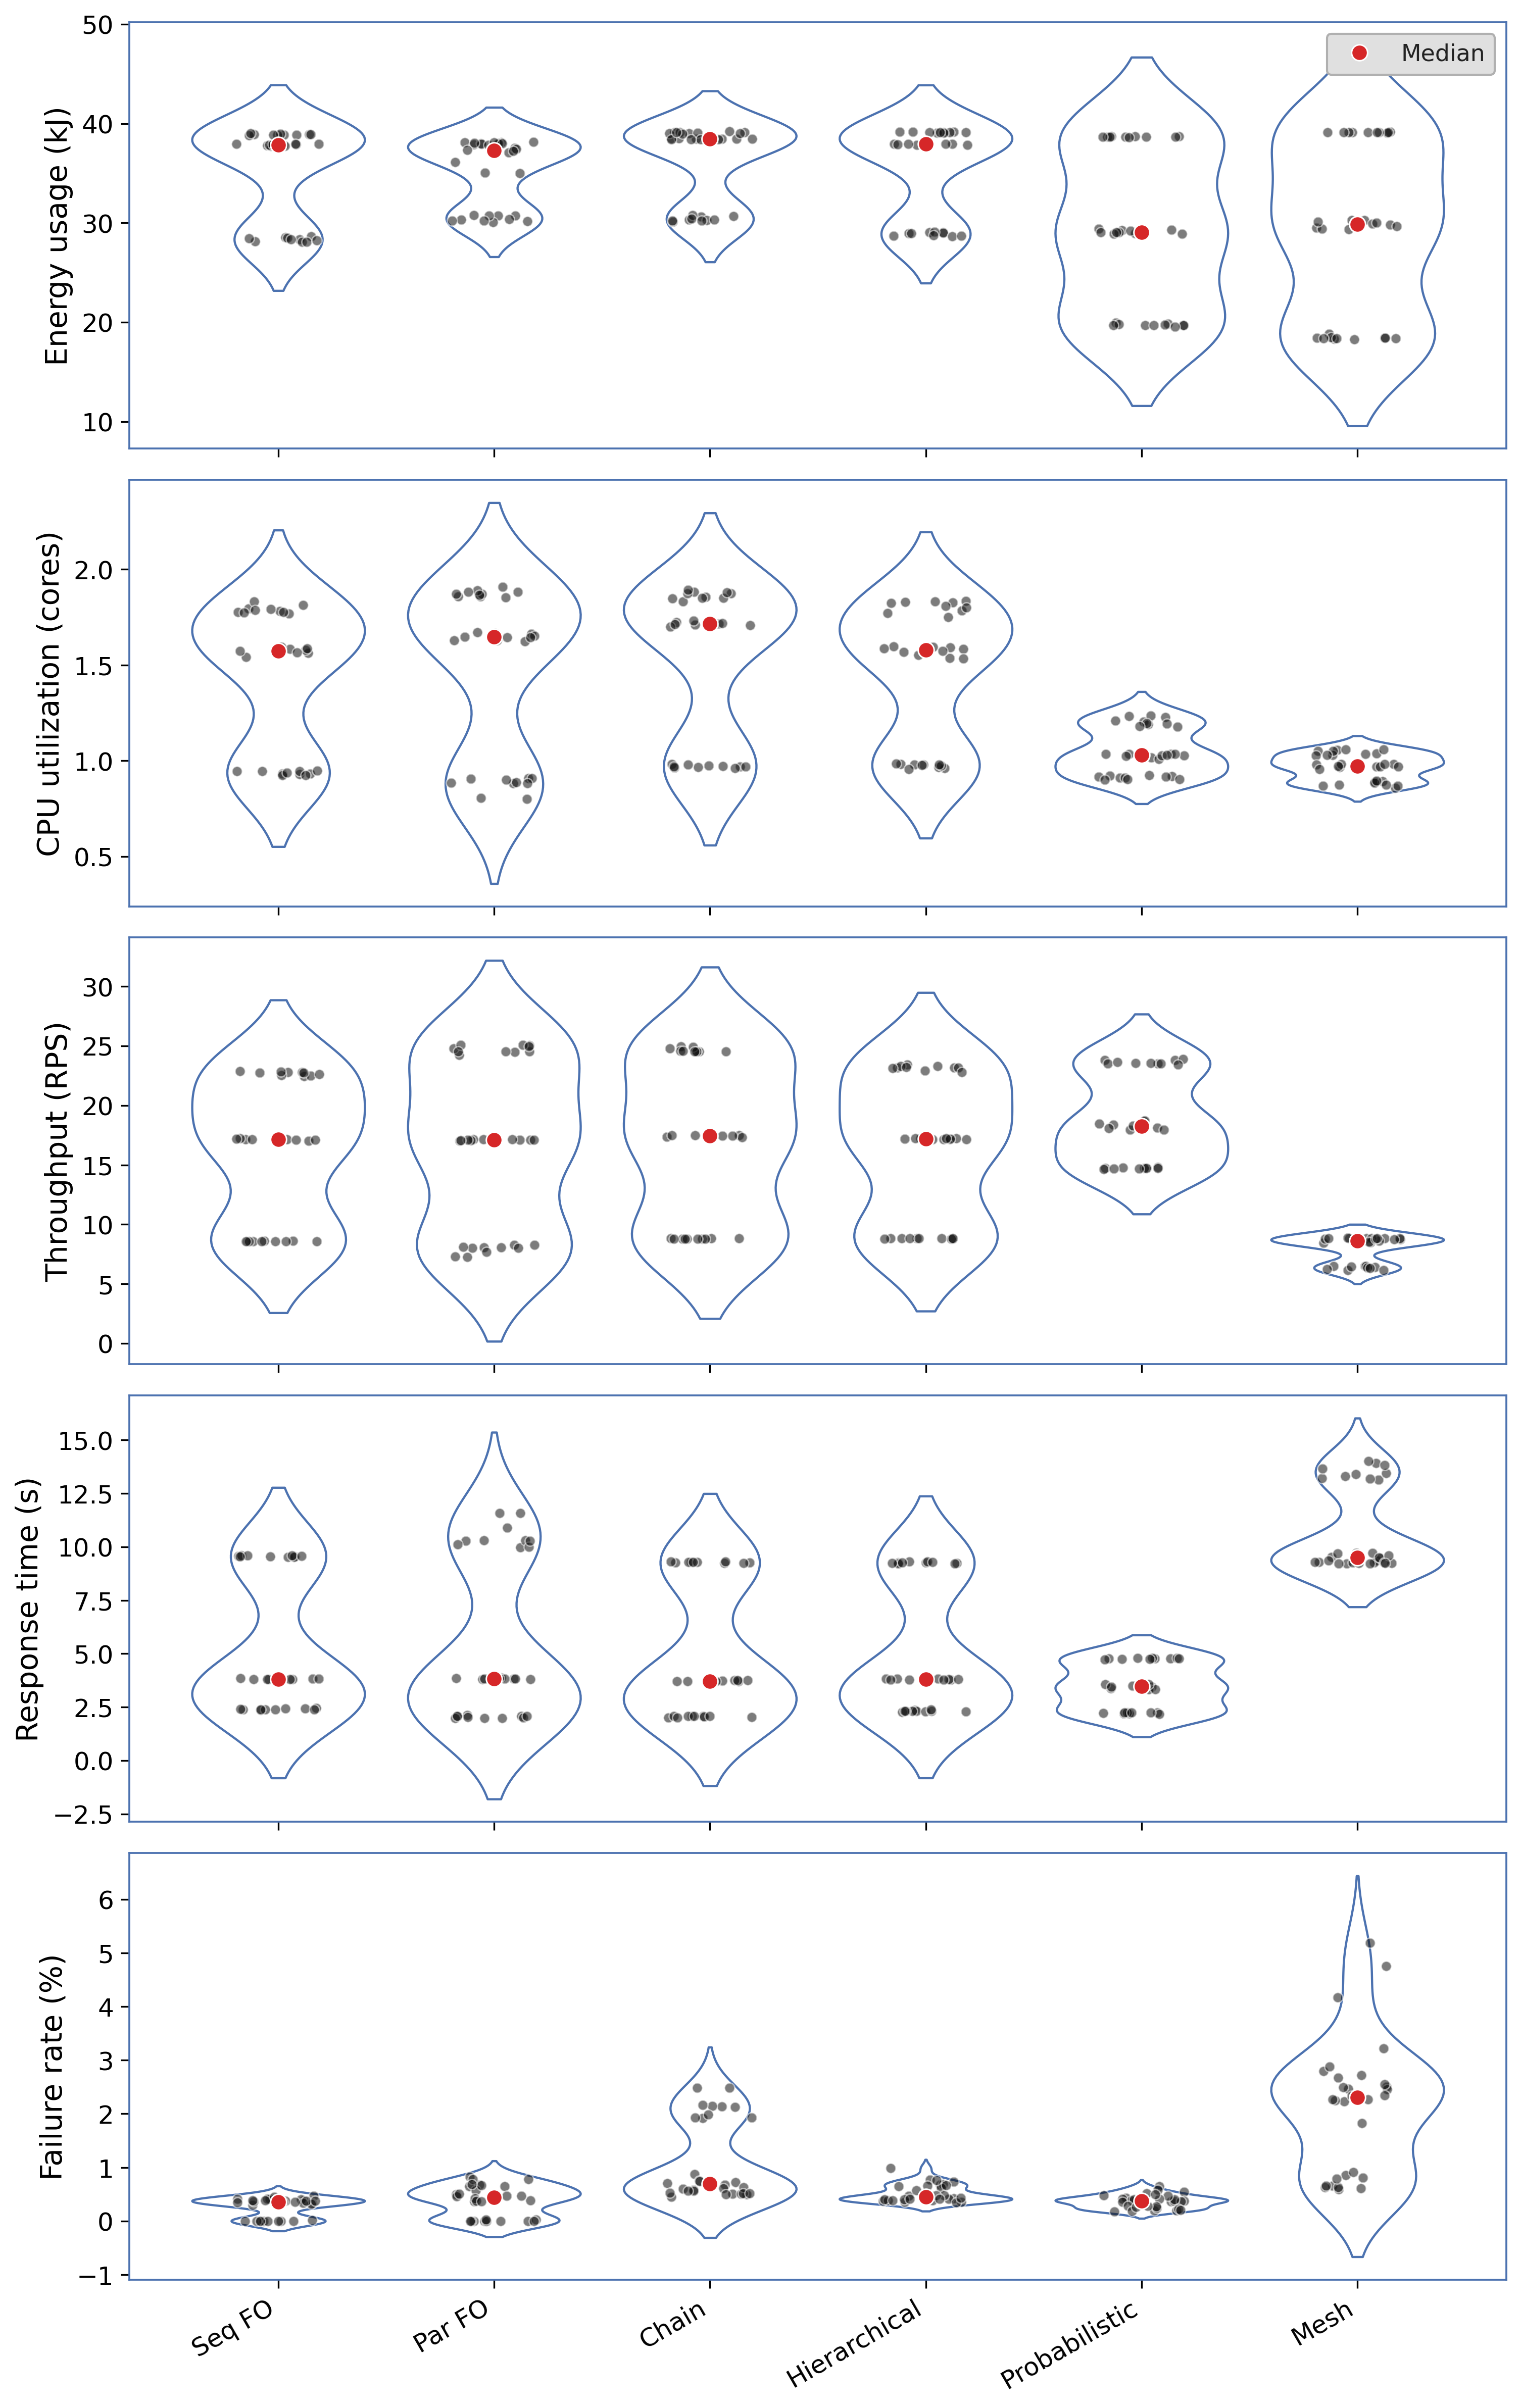

In [5]:
# Violins: scale='width' so each violin uses full slot width (not skinny area scaling).
# cut=2 tapered KDE; all points. Median marker slightly larger than strip (same s scaling as seaborn: size**2). No IQR box.
x_order = [TOPOLOGY_LABELS[t] for t in TOPOLOGY_ORDER]
BLUE = '#4C72B0'  # medium blue (matplotlib/seaborn default family)
PANEL_BG = 'white'
STRIP_FACE = '#111111'
STRIP_EDGE = 'white'
STRIP_SIZE = 4.8  # seaborn stripplot: passed to scatter as s=size**2
MEDIAN_SIZE_MULT = 1.58  # diameter vs strip; larger median dot for visibility
MEDIAN_MARKER_S = (STRIP_SIZE * MEDIAN_SIZE_MULT) ** 2
FS_YLABEL = 14
FS_TICK = 12
FS_LEGEND = 11
MEDIAN_COLOR = '#d62728'
MEDIAN_MARKER_EDGE = 'white'
MEDIAN_MARKER_EDGELW = 0.72


def draw_median_markers(ax, plot_df, x_labels):
    """Median as red scatter; larger s than strip for visibility."""
    xs, ys = [], []
    for i, lab in enumerate(x_labels):
        vals = plot_df.loc[plot_df['topology_label'] == lab, 'value'].dropna().values
        if len(vals) < 1:
            continue
        xs.append(float(i))
        ys.append(float(np.median(vals)))
    if xs:
        ax.scatter(
            xs, ys,
            s=MEDIAN_MARKER_S,
            c=MEDIAN_COLOR,
            edgecolors=MEDIAN_MARKER_EDGE,
            linewidths=MEDIAN_MARKER_EDGELW,
            zorder=5,
        )


metrics_to_plot = [(col, title) for col, title in METRIC_BLOCKS if col in df.columns]
if not metrics_to_plot:
    raise ValueError("No metric columns found in df")
n_metrics = len(metrics_to_plot)

fig, axs = plt.subplots(n_metrics, 1, figsize=(10, 3.2 * n_metrics), dpi=300, sharex=True)
fig.patch.set_facecolor('white')
if n_metrics == 1:
    axs = [axs]

for ax, (metric_col, metric_title) in zip(axs, metrics_to_plot):
    ax.set_facecolor(PANEL_BG)
    ax.grid(False)

    rows = []
    for topo in TOPOLOGY_ORDER:
        series = df[df['topology'] == topo][metric_col].dropna()
        for v in series:
            rows.append({'topology_label': TOPOLOGY_LABELS[topo], 'value': v})
    plot_df = pd.DataFrame(rows)
    if plot_df.empty:
        ax.set_ylabel(metric_title, fontsize=FS_YLABEL, fontweight='medium')
        continue

    sns.violinplot(
        data=plot_df,
        x='topology_label',
        y='value',
        order=x_order,
        ax=ax,
        inner=None,
        linewidth=1.05,
        color='white',
        edgecolor=BLUE,
        cut=2,
        scale='width',
    )
    for coll in ax.collections:
        if isinstance(coll, PolyCollection):
            coll.set_facecolor('white')
            coll.set_edgecolor(BLUE)
            coll.set_linewidth(1.05)
            coll.set_alpha(1.0)

    sns.stripplot(
        data=plot_df,
        x='topology_label',
        y='value',
        order=x_order,
        ax=ax,
        color=STRIP_FACE,
        size=STRIP_SIZE,
        jitter=0.2,
        alpha=0.55,
        linewidth=0.65,
        edgecolor=STRIP_EDGE,
        zorder=2,
    )

    draw_median_markers(ax, plot_df, x_order)
    ax.margins(y=0.06)

    ax.set_ylabel(metric_title, fontsize=FS_YLABEL, fontweight='medium')
    ax.tick_params(axis='both', labelsize=FS_TICK, width=0.8, length=4)
    ax.set_xlabel('')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color(BLUE)
        spine.set_linewidth(0.9)

legend_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        markerfacecolor=MEDIAN_COLOR,
        markeredgecolor=MEDIAN_MARKER_EDGE,
        markeredgewidth=MEDIAN_MARKER_EDGELW,
        markersize=STRIP_SIZE * MEDIAN_SIZE_MULT,
        linestyle='None',
        label='Median',
    ),
]
axs[0].legend(
    handles=legend_handles,
    loc='upper right',
    frameon=True,
    framealpha=1.0,
    fontsize=FS_LEGEND,
    facecolor='#e0e0e0',
    edgecolor='#b0b0b0',
    labelcolor='#222222',
)
labels = axs[-1].get_xticklabels()
axs[-1].set_xticklabels(labels, rotation=30, ha='right', fontsize=FS_TICK)

plt.tight_layout()
base = 'figure2_metrics_by_topology'
plt.savefig(FIGURES_DIR / f'{base}.pdf', dpi=300, bbox_inches='tight', facecolor=fig.patch.get_facecolor())
plt.savefig(FIGURES_DIR / f'{base}.png', dpi=300, bbox_inches='tight', facecolor=fig.patch.get_facecolor())
plt.show()
plt.close()